In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import t

np.random.seed(42)

In [2]:
class BlockingSystem():
    def __init__(self, m_service_time=8, m_arriving_time=1, num_servers=10, num_customers=10*10000):
        self.lamd = 1/m_arriving_time # mean inter-arrival time
        self.mu = 1/m_service_time # mean service time
        self.num_servers = num_servers
        self.num_customers = num_customers
        
        self.servers_available = self.num_servers # m
        self.servers_status = self.servers_status = np.zeros(self.num_servers)
        self.blocked = 0
        
    def sample_service_time(self): # ~ Exp(mu)
        U = np.random.rand()
        return -1* np.log(U) /self.mu 

    def sample_arrival_time(self): # ~ Exp(lamd)
        U = np.random.rand()
        return -1 * np.log(U) /self.lamd 
    
    
    def allocate_server(self, arrival_time, service_time):
        servers_available = np.sum(self.servers_status <= arrival_time) # Number of servers that are available at the time of arrival
        
        if servers_available > 0:
            bool = True
            allocated_server = np.argmin(self.servers_status)
            self.servers_status[allocated_server] = arrival_time + service_time
            
        else:
            bool = False
        return bool
    
    def blocking_probability(self):
        return self.blocked / ( self.num_customers)    
    
    def analytical_blocking_probability(self): 
        A = self.lamd / self.mu # lambda * s
        numerator = A**self.num_servers / math.factorial(self.num_servers)
        denominator = np.sum([A**i / math.factorial(i) for i in range(self.num_servers + 1)])
        
        
        return numerator / denominator # B = P(m)
    
    def reset(self):
        self.servers_status = np.zeros(self.num_servers)
        self.blocked = 0
        
    
    def simulate(self):
        t = 0
        c = 0
        self.event_array = np.zeros((self.num_customers, 2))
        arrival_times = np.zeros(self.num_customers)
        self.service_times = np.zeros(self.num_customers)
        
        for c in range(self.num_customers): # Each iteration corresponds to one customer
            
            
            customer = np.zeros(2) #arrival time, departure time
            
            c_arrival_time = self.sample_arrival_time()
            arrival_times[c] = c_arrival_time
            customer[0] = t + c_arrival_time
            service_time = self.sample_service_time()
            

            if self.allocate_server(customer[0], service_time):
                customer[1] = customer[0] + service_time
                self.service_times[c] = service_time
                
            else:
                customer[1] = -1
                self.blocked += 1
                self.service_times[c] = -1
                
            self.event_array[c, :] = customer
            
            
            
            t += c_arrival_time
            
    def plot_A_t(self, ax=None, t_max=10):
        if ax is None:
            ax = plt.gca()
        count = np.arange(1, self.num_customers + 1)
        ax.plot(self.event_array[:, 0], count, label='Arrivals')
        ax.plot(np.sort(self.event_array[:, 1][self.event_array[:, 1] != -1]), count[self.event_array[:, 1] != -1], label='Departures', c='green')
        ax.plot(self.event_array[:, 0][self.event_array[:, 1] == -1], count[:len(self.event_array[:, 0][self.event_array[:, 1] == -1])], label='Rejections', c='red')
        
        
        
        ax.set_xlabel('Time')
        ax.set_ylabel('Event Count')
        ax.set_xlim(0, t_max)
        ax.set_ylim(0, self.event_array[:, 0][self.event_array[:, 0] <= t_max].shape[0]*1.1)
        ax.set_title(f'Events Over Time with $\\mu={self.mu}$, $\\lambda={self.lamd}$, $m={self.num_servers}$')
        ax.legend()
        ax.grid()
        #plt.show()
    
    def plot_inter_times(self, ax=None):
        if ax is None:
            ax = plt.gca()
        inter_arrival_times = np.diff(self.event_array[:, 0])
        inter_departure_times = np.diff(np.sort(self.event_array[:, 1][self.event_array[:, 1] != -1]))
        
        ax.hist(inter_arrival_times, bins=50, density=True, alpha=0.6, color='g', label='Inter-arrival Times')
        ax.hist(inter_departure_times, bins=50, density=True, alpha=0.6, color='b', label='Inter-departure Times')
        
        ax.set_title('Inter-arrival and Inter-departure Times Distribution')
        ax.set_xlabel('Time')
        ax.set_ylabel('Density')
        ax.grid()
        ax.legend()
        plt.show()
            
            

In [3]:
num_simulations = 100
blocking_probs = np.zeros(num_simulations)
blocking_system = BlockingSystem()

for i in range(num_simulations):
    blocking_system.reset()
    blocking_system.simulate()
    blocking_probs[i] = blocking_system.blocking_probability()

mean_blocking_prob = np.mean(blocking_probs)
std_blocking_prob = np.std(blocking_probs, ddof=1)
print(f"Mean blocking probability: {mean_blocking_prob:.4f}")
print(f"Analytical solution: {blocking_system.analytical_blocking_probability():.4f}")



t_test_statistic = t.ppf(1 - 0.05/2, df=num_simulations-1)
CI = (mean_blocking_prob - t_test_statistic*std_blocking_prob/np.sqrt(num_simulations), mean_blocking_prob + t_test_statistic*std_blocking_prob/np.sqrt(num_simulations))

print(f"95% CI: [{CI[0]:.4f}, {CI[1]:.4f}]")



Mean blocking probability: 0.1214
Analytical solution: 0.1217
95% CI: [0.1211, 0.1218]


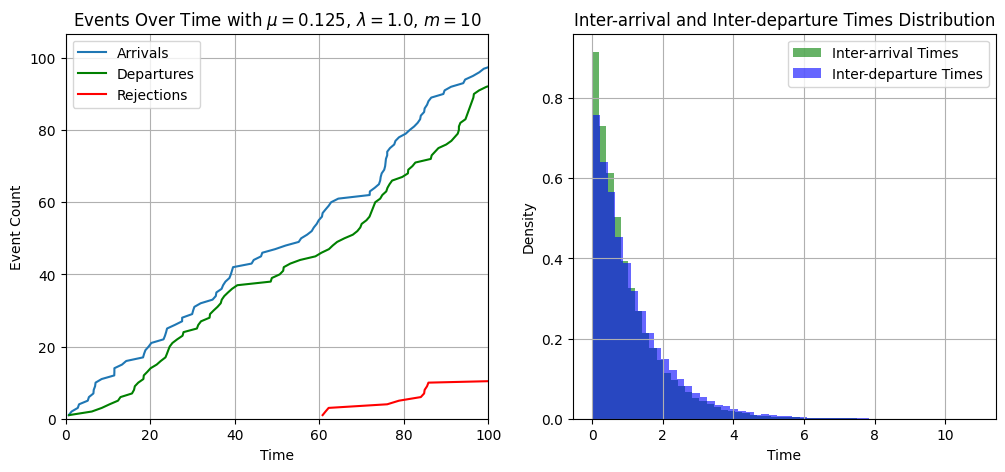

<Figure size 640x480 with 0 Axes>

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

blocking_system.plot_A_t(ax=ax[0], t_max=100)
blocking_system.plot_inter_times(ax=ax[1])

plt.tight_layout()
plt.show();